CUSTOMER SEGMENTATION ANALYSIS

[STEP 1] Loading Dataset...
Dataset loaded successfully!!!
  Shape: (2205, 39)

First 5 rows:
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4       

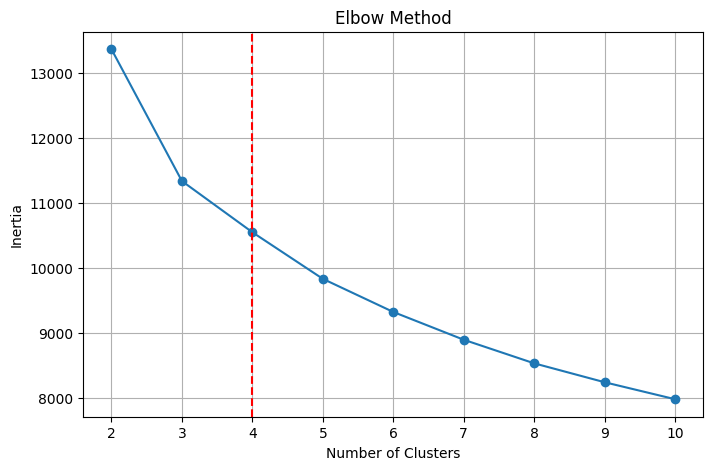


[STEP 6] Applying K-Means Clustering...
✓ Customers segmented into 4 clusters

Cluster Distribution:
Cluster
0    499
1    312
2    299
3    911
Name: count, dtype: int64

[STEP 7] Analyzing Customer Segments...

Cluster Summary:
               Income    Recency    MntWines  MntFruits  MntMeatProducts  \
Cluster                                                                    
0        56359.292585  47.120240  387.629259  17.977956       115.222445   
1        74673.692308  51.054487  773.477564  39.150641       427.766026   
2        73696.137124  48.729097  496.929766  93.638796       419.785953   
3        34032.190999  49.150384   39.612514   4.499451        21.001098   

         MntFishProducts  MntSweetProducts  MntGoldProds  NumWebPurchases  \
Cluster                                                                     
0              25.959920         18.539078     55.917836         6.258517   
1              57.557692         41.416667     64.086538         5.416667   
2   

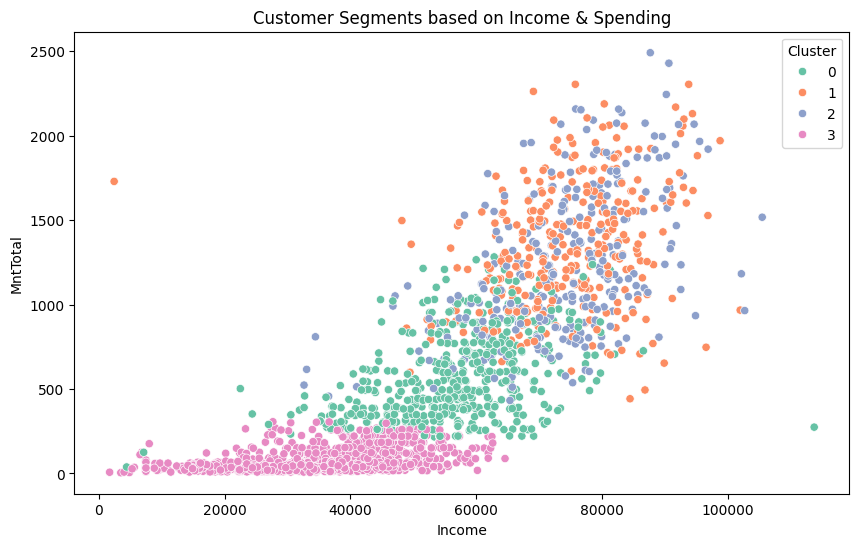

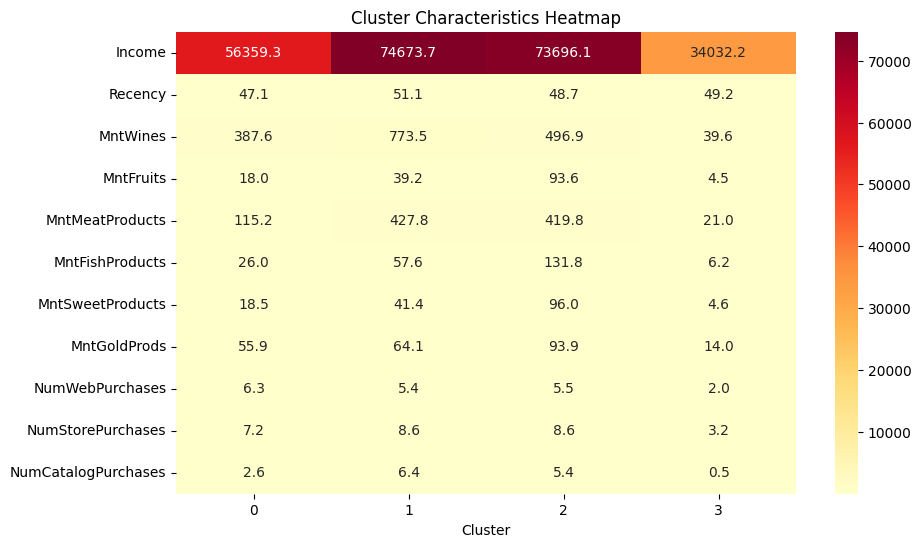


[STEP 9] Customer Segment Profiling...

CLUSTER 0: Low-Value / Budget Customers
Number of Customers: 499
Income                 56359.292585
Recency                   47.120240
MntWines                 387.629259
MntFruits                 17.977956
MntMeatProducts          115.222445
MntFishProducts           25.959920
MntSweetProducts          18.539078
MntGoldProds              55.917836
NumWebPurchases            6.258517
NumStorePurchases          7.234469
NumCatalogPurchases        2.561122
dtype: float64

CLUSTER 1: High-Value Premium Customers
Number of Customers: 312
Income                 74673.692308
Recency                   51.054487
MntWines                 773.477564
MntFruits                 39.150641
MntMeatProducts          427.766026
MntFishProducts           57.557692
MntSweetProducts          41.416667
MntGoldProds              64.086538
NumWebPurchases            5.416667
NumStorePurchases          8.564103
NumCatalogPurchases        6.355769
dtype: float64

CLUST

In [5]:
# Customer Segmentation Analysis - Oasis Infobyte Internship
# Project:Customer Segmentation using K-Means Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CUSTOMER SEGMENTATION ANALYSIS")
print("="*70)

# ============================================================================
# STEP 1: DATA LOADING AND EXPLORATION
# ============================================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv('ifood_df.csv')

print("Dataset loaded successfully!!!")
print(f"  Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================================================================
# STEP 2: DATA CLEANING
# ============================================================================
print("\n[STEP 2] Data Cleaning...")

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna()
duplicates = df.duplicated().sum()
df = df.drop_duplicates()

print(f" Rows after cleaning: {len(df)}")
print(f" Removed {duplicates} duplicate rows")

# ============================================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================================
print("\n[STEP 3] Feature Engineering...")

df_segmentation = df.copy()
print(" Features prepared for segmentation")
print(f"  Shape: {df_segmentation.shape}")

# ============================================================================
# STEP 4: FEATURE SELECTION AND SCALING (MODIFIED)
# ============================================================================
print("\n[STEP 4] Feature Selection and Scaling...")

# IMPORTANT: Business-driven features only
numerical_features = [
    'Income',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases'
]

print(f"Features used for clustering: {numerical_features}")

X = df_segmentation[numerical_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled using StandardScaler")
print(f"  Feature matrix shape: {X_scaled.shape}")

# ============================================================================
# STEP 5: CLUSTER SELECTION (MODIFIED)
# ============================================================================
print("\n[STEP 5] Determining Optimal Number of Clusters...")

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Business-aligned choice
optimal_k = 4
print(f"Optimal number of clusters selected: {optimal_k}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# ============================================================================
# STEP 6: APPLYING K-MEANS CLUSTERING
# ============================================================================
print("\n[STEP 6] Applying K-Means Clustering...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_segmentation['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✓ Customers segmented into {optimal_k} clusters")
print("\nCluster Distribution:")
print(df_segmentation['Cluster'].value_counts().sort_index())

# ============================================================================
# STEP 7: CLUSTER ANALYSIS
# ============================================================================
print("\n[STEP 7] Analyzing Customer Segments...")

cluster_analysis = df_segmentation.groupby('Cluster')[numerical_features].mean()
cluster_sizes = df_segmentation['Cluster'].value_counts().sort_index()
cluster_analysis['Customer_Count'] = cluster_sizes.values

print("\nCluster Summary:")
print(cluster_analysis)

# ============================================================================
# STEP 8: VISUALIZATION
# ============================================================================
print("\n[STEP 8] Creating Visualizations...")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Income',
    y='MntTotal',
    hue='Cluster',
    data=df_segmentation,
    palette='Set2'
)
plt.title("Customer Segments based on Income & Spending")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_analysis[numerical_features].T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title("Cluster Characteristics Heatmap")
plt.show()

# ============================================================================
# STEP 9: SEGMENT PROFILING (MODIFIED)
# ============================================================================
print("\n[STEP 9] Customer Segment Profiling...")

segment_names = {
    0: "Low-Value / Budget Customers",
    1: "High-Value Premium Customers",
    2: "Mid-Value Customers",
    3: "High-Income Selective Buyers"
}

for i in range(optimal_k):
    print("\n" + "="*70)
    print(f"CLUSTER {i}: {segment_names[i]}")
    print("="*70)
    
    cluster_data = df_segmentation[df_segmentation['Cluster'] == i]
    print(f"Number of Customers: {len(cluster_data)}")
    print(cluster_data[numerical_features].mean())

# ============================================================================
# STEP 10: INSIGHTS & RECOMMENDATIONS
# ============================================================================
print("\n[STEP 10] Insights and Recommendations")

print("""
• Premium customers contribute the highest overall spending.
• Budget customers show low spending but high frequency potential.
• High-income selective buyers prefer fewer but high-value purchases.

RECOMMENDATIONS:
1. Loyalty programs for premium customers
2. Discount campaigns for budget customers
3. Personalized offers for high-income selective buyers
4. Upselling strategies for mid-value customers
""")

# ============================================================================
# STEP 11: SAVE RESULTS
# ============================================================================
print("\n[STEP 11] Saving Results...")

df_segmentation.to_csv('customer_segments.csv', index=False)
cluster_analysis.to_csv('cluster_analysis.csv')

print("Files saved successfully")
print("\nCUSTOMER SEGMENTATION ANALYSIS COMPLETED!!!")
